In [9]:
import matplotlib.pyplot as plt
import numpy as np

In [10]:
AP_1000_costs = [8900, 11450, 14070]
EPR_costs = [14150, 17300]
APR_costs = [8600]

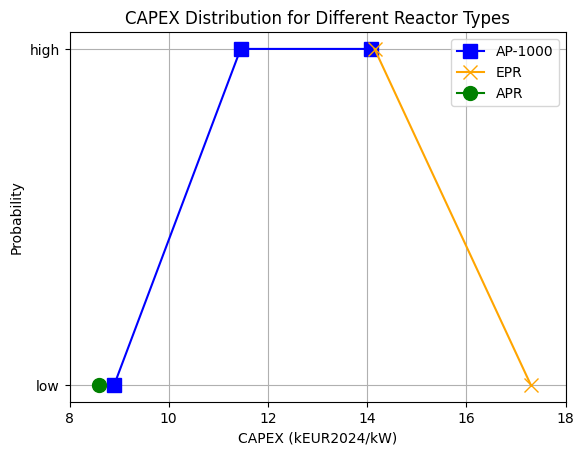

In [11]:
# plot all as points (cost on the x, 1 on the y)
plt.plot(AP_1000_costs, [0,1,1], label='AP-1000', color='blue', marker='s', markersize=10)
plt.plot(EPR_costs, [1,0], label='EPR', color='orange', marker='x', markersize=10)
plt.plot(APR_costs, [0], label='APR', color='green', marker='o', markersize=10)  
plt.xlabel('CAPEX (kEUR2024/kW)')
min_x = min(min(AP_1000_costs), min(EPR_costs), min(APR_costs))
max_x = max(max(AP_1000_costs), max(EPR_costs), max(APR_costs))
start = int(min_x // 1000 * 1000)
end = int((max_x + 1999) // 1000 * 1000)
ticks = list(range(start, end + 1, 2000))
plt.xticks(ticks, [f'{t/1000:g}' for t in ticks])
plt.ylabel('Probability')
plt.yticks([0,1], ['low', 'high'])
plt.title('CAPEX Distribution for Different Reactor Types')
plt.legend()
plt.grid()
plt.savefig('reactor_capex_distribution.pdf')
plt.show()


In [12]:
scale_down = (11450 - 8900)/11450
print("AP-1000 scale down:", scale_down)

AP-1000 scale down: 0.22270742358078602


In [13]:
range_mid_AP = -(11450 - 14070)/11450
range_mid_EPR = -(14150 - 17300)/14150
range_mid = (range_mid_EPR + range_mid_AP) /2
print(range_mid)

0.22571790084404464


In [14]:
def fill_missing_values(vector, scale_down, range_mid):
    filled_vector = vector.copy()

    # If the fourth value is known, backfill the third
    if filled_vector[3] is not None and filled_vector[2] is None:
        filled_vector[2] = filled_vector[3] / 1.2

    # If the third value is known, fill the fourth if missing
    if filled_vector[2] is not None and filled_vector[3] is None:
        filled_vector[3] = filled_vector[2] * 1.2

    # If only the first value is known, fill step by step
    if filled_vector[0] is not None and filled_vector[1] is None and filled_vector[2] is None and filled_vector[3] is None:
        filled_vector[1] = filled_vector[0] / (1 - scale_down)
        filled_vector[2] = filled_vector[1] * (1 + range_mid)
        filled_vector[3] = filled_vector[2] * 1.2

    # If the second value is missing, fill it from the first or third
    if filled_vector[1] is None:
        if filled_vector[0] is not None:
            filled_vector[1] = filled_vector[0] / (1 - scale_down)

        elif filled_vector[2] is not None:
            filled_vector[1] = filled_vector[2] / (1 + range_mid)

    # If the first value is missing, fill it from the second
    if filled_vector[0] is None and filled_vector[1] is not None:
        filled_vector[0] = filled_vector[1] * (1 - scale_down)
        if filled_vector[2] is None:
            filled_vector[2] = filled_vector[1] * (1 + range_mid)
        if filled_vector[3] is None:
            filled_vector[3] = filled_vector[2] * 1.2

    return filled_vector


AP-1000 costs after filling missing values: [8900, 11500, 14100, 16920.0] (area=5310, height=0.000188324)
EPR costs after filling missing values: [9004.971353973244, 11585.0474160667, 14200, 17300] (area=5454.99, height=0.000183318)
APR costs after filling missing values: [8600, 11064.044943820225, 13561.397943383492, 16273.67753206019] (area=5085.52, height=0.000196637)
BWRX costs after filling missing values: [8627.947598253275, 11100, 13605.468699368896, 16326.562439242674] (area=5102.04, height=0.000196)
Rolls Royce costs after filling missing values: [8000, 10292.134831460673, 12615.253900821852, 15138.30468098622] (area=4730.71, height=0.000211385)
Nuscale costs after filling missing values: [4100, 5274.7191011235955, 16500.0, 19800] (area=13462.6, height=7.42796e-05)


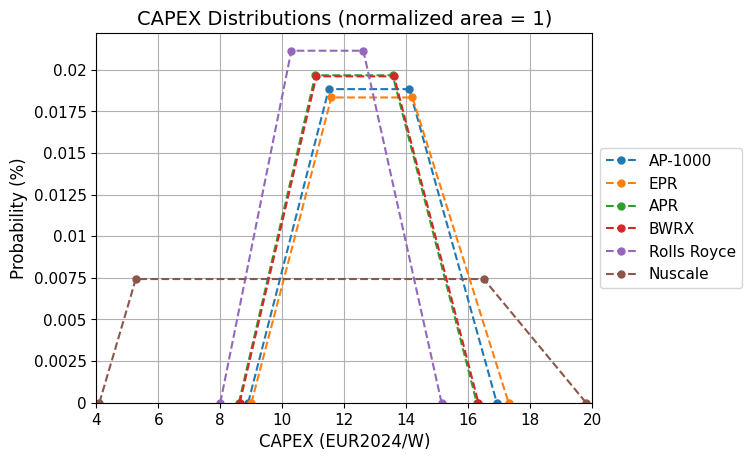

In [25]:
AP_1000_costs = [8900, 11500, 14100, None]
EPR_costs = [None, None, 14200, 17300]
APR_costs = [8600, None, None, None]
BWRX_costs = [None, 11100, None, None]
RR_costs = [8000, None, None, None]
Nuscale_costs = [4100, None, None, 19800]

costs = [AP_1000_costs, EPR_costs, APR_costs, BWRX_costs, RR_costs, Nuscale_costs]

from matplotlib.ticker import FuncFormatter

labels = ['AP-1000', 'EPR', 'APR', 'BWRX','Rolls Royce', 'Nuscale']
for i, c in enumerate(costs):
    c_complete = fill_missing_values(c, scale_down, range_mid)
    x = np.array(c_complete, dtype=float)
    y = np.array([0.0, 1.0, 1.0, 0.0], dtype=float)
    area = np.trapezoid(y, x)
    y = y / area
    print(f"{labels[i]} costs after filling missing values: {c_complete} (area={area:g}, height={1/area:g})")
    plt.plot(x, y, label=labels[i], marker='o', markersize=5, linestyle='--')
plt.xlabel('CAPEX (EUR2024/W)')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:g}'))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:g}'))
plt.ylabel('Probability (%)')
plt.title('CAPEX Distributions (normalized area = 1)')
plt.xlim(4000, 20000)
# Increase the font size on all labels
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11
})

plt.ylim(0, None)
plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()
plt.show()

AP-1000 costs after filling missing values: [8900, 11500, 14100, 16920.0]


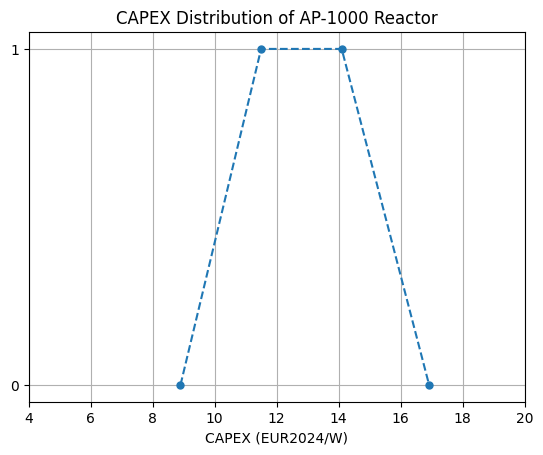

EPR costs after filling missing values: [9004.971353973244, 11585.0474160667, 14200, 17300]


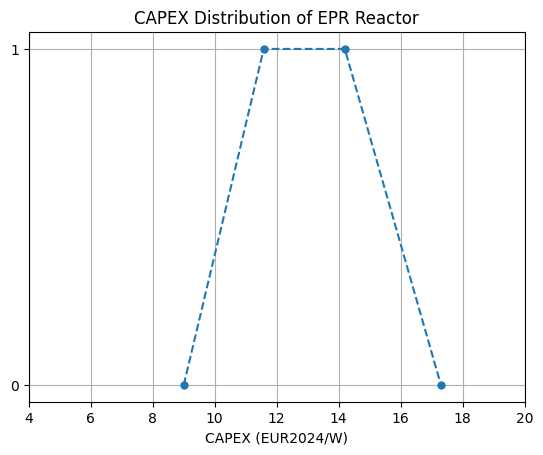

APR costs after filling missing values: [8600, 11064.044943820225, 13561.397943383492, 16273.67753206019]


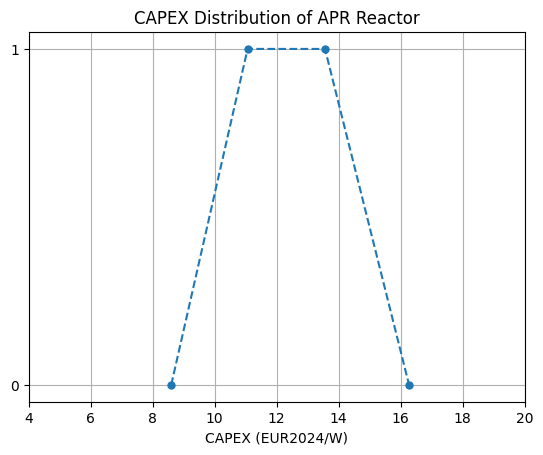

BWRX costs after filling missing values: [8627.947598253275, 11100, 13605.468699368896, 16326.562439242674]


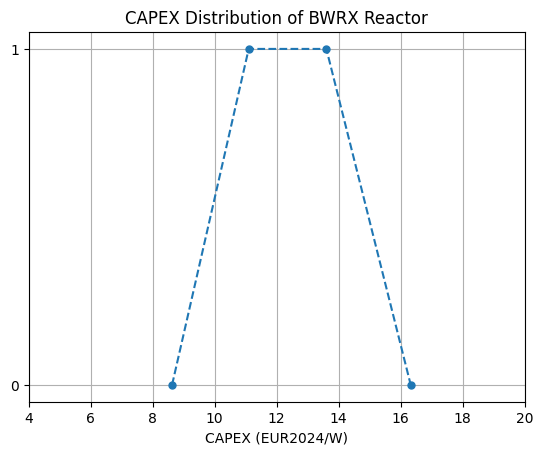

Rolls Royce costs after filling missing values: [8000, 10292.134831460673, 12615.253900821852, 15138.30468098622]


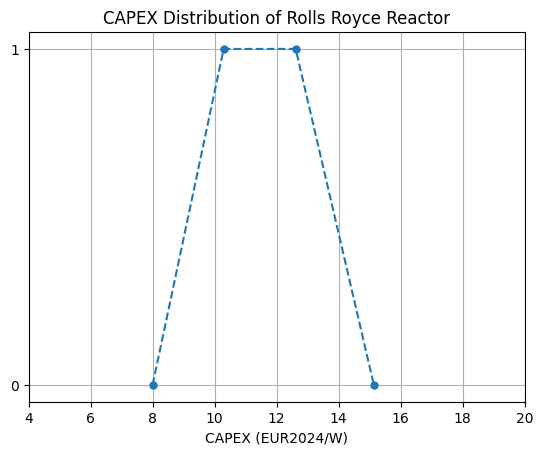

Nuscale costs after filling missing values: [4100, 5274.7191011235955, 16500.0, 19800]


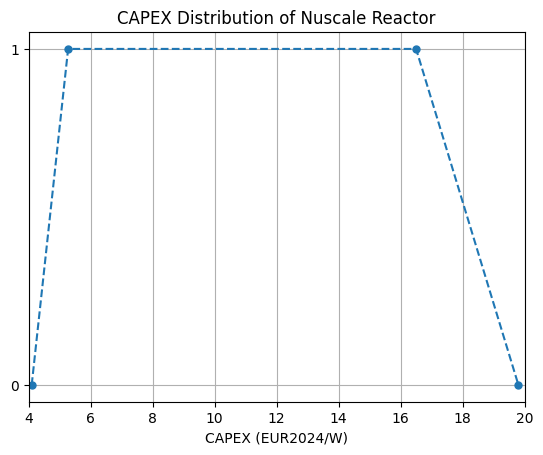

In [16]:
from matplotlib.ticker import FuncFormatter

labels = ['AP-1000', 'EPR', 'APR', 'BWRX','Rolls Royce', 'Nuscale']
for i, c in enumerate(costs):
    c_complete = fill_missing_values(c, scale_down, range_mid)
    print(f"{labels[i]} costs after filling missing values: {c_complete}")
    plt.plot(c_complete, [0,1,1,0], label=labels[i], marker='o', markersize=5, linestyle='--')
    plt.xlabel('CAPEX (EUR2024/W)')
    plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:g}'))
    plt.yticks([0,1])  # hide y-axis ticks
    plt.title(f'CAPEX Distribution of {labels[i]} Reactor')
    plt.xlim(4000, 20000)
    plt.grid()
    plt.show()